In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["axes.grid"] = False
sc.settings.set_figure_params(dpi=80, dpi_save=180, vector_friendly=True, transparent=True) #for figures

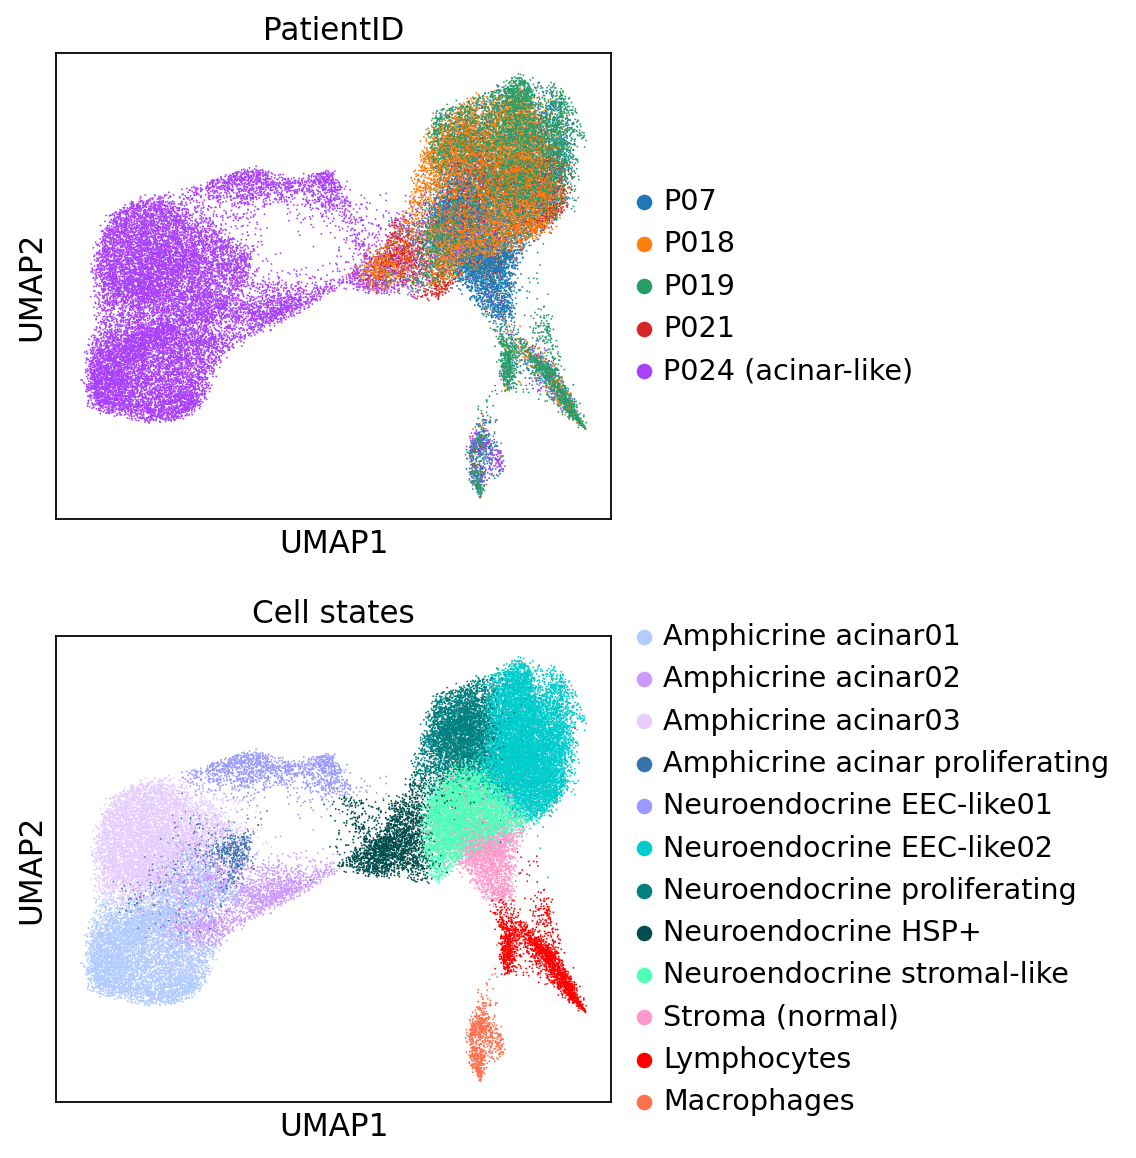

In [2]:
results= "./pnec_anndata_082023/pNEC_updated_annot_07082023.h5ad"
adata= sc.read_h5ad(results)
sc.pl.umap(adata, color= ['PatientID', 'Cell states'], ncols=1)

In [3]:
#Re-name the cell states: 
adata.obs['Cell states'] = (adata.obs["Cell states"].map(lambda x: {"Neuroendocrine HSP+": "Neuroendocrine HSP+ (hypoxic)",
                     "Neuroendocrine EEC-like01": "Amphicrine progenitor-like",
                    "Neuroendocrine EEC-like02": "Neuroendocrine"   }.get(x, x)).astype("category"))

adata.obs['Cell states'].cat.categories

Index(['Amphicrine acinar01', 'Amphicrine acinar02', 'Amphicrine acinar03',
       'Amphicrine acinar proliferating', 'Amphicrine progenitor-like',
       'Neuroendocrine', 'Neuroendocrine proliferating',
       'Neuroendocrine HSP+ (hypoxic)', 'Neuroendocrine stromal-like',
       'Stroma (normal)', 'Lymphocytes', 'Macrophages'],
      dtype='object')

In [4]:
#Get back raw data & normalize:
adata_norm= adata.raw.to_adata()
sc.pp.normalize_total(adata_norm, target_sum=1e4)
sc.pp.log1p(adata_norm)

**Drug target enrichment (UMAP scoring)**

WebGestalt GSEA was run with the following parameters: redundancy removal by weighted set cover (fast); minimum 5 & maximum 2000 analytes per category; significance threshold FDR < 0.05; 1000 permutations; p = 1; collapse method = mean; 10 categories expected from set cover. 

Using WebGestalt (GSEA; http://www.webgestalt.org), we identified three drug targets that were both statistically significant (FDR < 0.05) & therapeutically meaningful: Cisplatin (NE proliferating), Geldanamycin (NE HSP+), and Tanespimycin (NE HSP+). 

The full ranked gene list per cluster was uploaded to the Input ID List. GSEA enrichment plots for each drug were exported directly from the WebGestalt webserver. Genes inferred as the drug targets from the WebGestalt enrichment output were used to compute a per-cell feature (module) score, which was visualized by overlaying the score onto the UMAP embedding to identify regions of concentrated target expression (circled). 

In [5]:
Cisplatin_targets= ['RRM2', 'FANCA', 'BRIP1', 'EZH2', 'BARD1', 'BRCA1', 'RAD18']
Geldanamycin= ['HSPA1B', 'HSP90AB1', 'HSP90AA1', 'HSPA9', 'HSPA4', 'PTGES3']
tanespimycin= ['HSPB1', 'HSP90AB1', 'HSP90AA1', 'HSPA4', 'PTGES3']


sc.tl.score_genes(adata_norm, Cisplatin_targets, score_name= "Cisplatin targets")
sc.tl.score_genes(adata_norm, Geldanamycin, score_name= "Geldanamycin targets")
sc.tl.score_genes(adata_norm, tanespimycin, score_name= "Tanespimycin targets")

#### Overlay drug target signature scores on UMAP

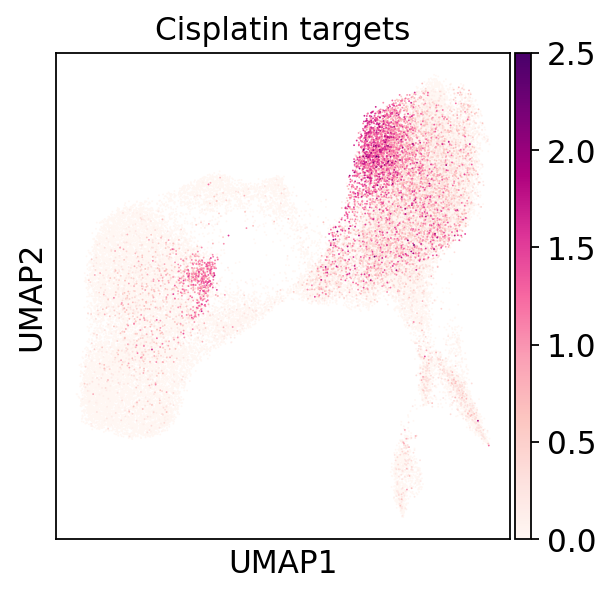

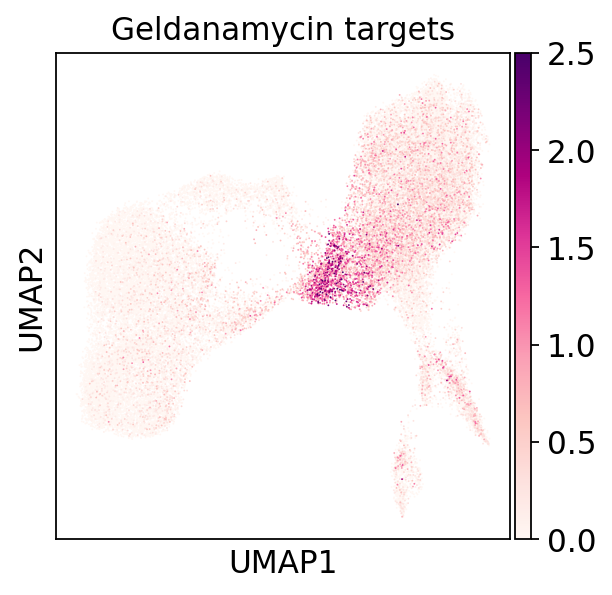

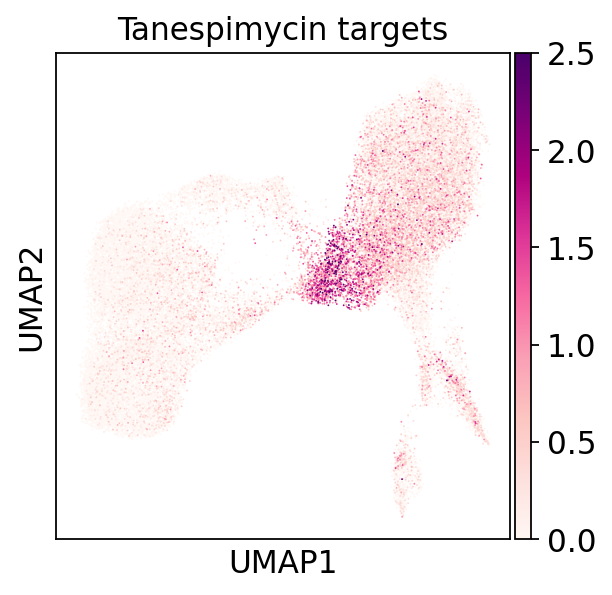

In [6]:
sc.pl.umap(adata_norm, color= ['Cisplatin targets'], ncols=1, vmin=0, vmax=2.5, cmap= "RdPu",
                              save= "_Cisplatin_targets_200224.pdf")

sc.pl.umap(adata_norm, color= ['Geldanamycin targets'], ncols=1, vmin=0, vmax=2.5, cmap= "RdPu",
                              save= "_Geldanamycin_targets_200224.pdf")

sc.pl.umap(adata_norm, color= ['Tanespimycin targets'], ncols=1, vmin=0, vmax=2.5, cmap= "RdPu",
                              save= "_Tanespimycin_targets_200224.pdf")